# Task 2: Where to place up to 12 extra vehicles

**Question.** The service can fund up to 12 extra vehicles, VSAV or FPT, spread freely over its 30 centres.
Three objectives, all to minimise: the P90 of SAP response times, the number of unanswered fires, and the number
of vehicles bought. The answer is a Pareto front and 3 or 4 configurations to recommend.

**Tool.** The coverage simulator replays a plausible year under a given reinforcement. Two identical calls give
different results, and 2000 replays must cover the whole test, Act 3 included. So the budget is planned before it
is spent, and every result is a mean over several replays with its 95% interval.

**Method.** A simulation-optimisation loop: the simulator scores a placement, a search proposes the next one.
Selene Cerna Ñahuis's thesis at FEMTO-ST (2022, with the Doubs fire service) used this family of methods on real
problems: an operational-load simulator, ambulance redeployment, the placement of a new centre. The three-objective
set-up below is this test's own simplified formulation, inspired by that family, not a copy of her work.

| Step | Planned | Used | Purpose |
|---|---|---|---|
| Noise and checks | 50 | 50 + 40 | Baseline, 12 VSAV, 12 FPT. The 40 were added after the screening raised a doubt. |
| Screening | 180 | 180 | Every single addition: 30 centres x 2 types, 3 replays each |
| Greedy build | about 300 | 360 | One vehicle at a time, re-testing the 5 most promising centres, 3 replays each |
| Confirmation | about 200 | 240 | Each retained placement again, 10 fresh replays |
| Final check | 80 | 80 | The recommended configurations, 20 replays each |
| Kept back | 600 | | Act 3 and surprises. The code refuses any call that would eat into it. |

Greedy build and confirmation used more than planned because the FPT search was extended to 12 vehicles (step 3).

In [1]:
import numpy as np
import pandas as pd
import helpers as h
import figures as fg
import simulation as sim

RESERVE = 600  # replays kept for Act 3; sim.evaluate() refuses a call that would go below it
raw = h.load_raw()
iv = h.build_interventions(raw)
centres = raw["centres"]["code_cis"].tolist()
pd.set_option("display.max_colwidth", None)


def show(runs: dict) -> pd.DataFrame:
    # Mean ± 95% half-width of each objective, one row per configuration
    out = {}
    for label, r in runs.items():
        out[label] = {
            "vehicles": int(r["vehicles"]), "replays": int(r["n"]),
            "P90 SAP (min)": f"{r['p90']:.2f} ± {sim.half_width(r['p90_sd'], r['n']):.2f}",
            "unanswered fires": f"{r['inc']:.0f} ± {sim.half_width(r['inc_sd'], r['n']):.0f}",
        }
    return pd.DataFrame(out).T

## 1. Noise, and does the simulator agree with the data?

Before any search: the baseline (no reinforcement) to measure the noise and compare with 2025, then two extreme
configurations. To build them I use the 2025 data from Task 1, which says where each vehicle type was short:

- **VSAV**: late SAP calls (above the P90) in a centre's first-call communes that went to another centre, although
  that centre normally gets there in time. Its own VSAV was busy.
- **FPT**: unanswered fires in communes where the centre is among the first three of the plan.

In [2]:
plan = raw["plan_deploiement"]
rank1 = plan[plan["rang"] == 1].set_index("insee")["code_cis"]
sap = iv[iv["reason"] == "SAP"].assign(r1=lambda d: d["insee"].map(rank1))
p90_2025 = np.percentile(sap["delay_min"], 90)
own = sap[sap["first_centre"] == sap["r1"]].groupby("insee")["delay_min"].median()
busy = sap[(sap["first_centre"] != sap["r1"]) & (sap["delay_min"] > p90_2025) & (sap["insee"].map(own) < p90_2025)]
missed_fires = iv[(iv["reason"] == "INC") & iv["unfulfilled"]].groupby("insee").size()
prior = pd.DataFrame({
    "VSAV": busy.groupby("r1").size(),
    "FPT": plan[plan["rang"] <= 3].assign(m=lambda d: d["insee"].map(missed_fires)).groupby("code_cis")["m"].sum(),
}).reindex(centres).fillna(0)

V12 = {c: {"VSAV": 1} for c in prior["VSAV"].nlargest(12).index}
F12 = {c: {"FPT": 1} for c in prior["FPT"].nlargest(12).index}
base_1 = sim.evaluate({}, 30, tag="A_noise", reserve=RESERVE)
step1 = {"baseline": base_1,
         "+12 VSAV": sim.evaluate(V12, 10, tag="A_noise", reserve=RESERVE),
         "+12 FPT": sim.evaluate(F12, 10, tag="A_noise", reserve=RESERVE)}
print(f"2025 data: P90 SAP {p90_2025:.2f} min, unanswered fires {missed_fires.sum()}")
show(step1)

2025 data: P90 SAP 25.51 min, unanswered fires 290


,vehicles,replays,P90 SAP (min),unanswered fires
baseline,0,30,25.58 ± 0.07,298 ± 5
+12 VSAV,12,10,21.54 ± 0.15,302 ± 14
+12 FPT,12,10,25.60 ± 0.21,3 ± 2


- **The simulator reproduces 2025.** Baseline P90 25.58 min and 298 unanswered fires, against 25.51 and 290 in
  the data. One replay varies by about 0.2 min on the P90 and 15 fires, so single replays are not enough.
- **Each objective depends on one vehicle type.** 12 extra FPT leave the P90 where it was, 12 extra VSAV leave the
  fires where they were. Task 1 showed the same in the data: SAP calls are always answered first by a VSAV, fires by
  an FPT. So the problem splits in two: where to put VSAVs for the P90, where to put FPTs for the fires.
- **The stakes are uneven.** 12 FPT remove nearly all unanswered fires (298 to 3). 12 VSAV take 4 min off the P90.

## 2. Screening: one vehicle, one centre, one type

60 configurations, 3 replays each. This shows where a single vehicle helps, and gives the starting point of the
search in step 3.

In [3]:
screen = pd.DataFrame([
    {"type": t, "centre": c, **sim.evaluate({c: {t: 1}}, 3, tag="B_screen", reserve=RESERVE)}
    for t in sim.TYPES for c in centres
])
vs = screen[screen["type"] == "VSAV"].set_index("centre")
fp = screen[screen["type"] == "FPT"].set_index("centre")
top = pd.concat([
    vs["p90"].nsmallest(8).round(2).rename("P90").reset_index().add_prefix("VSAV "),
    fp["inc"].nsmallest(8).round(0).rename("fires").reset_index().add_prefix("FPT "),
], axis=1)
rho = {t: prior[t].corr(-(vs["p90"] if t == "VSAV" else fp["inc"]), method="spearman") for t in sim.TYPES}
print("Rank agreement with the 2025 data prior (Spearman):", ", ".join(f"{t} {r:.2f}" for t, r in rho.items()))
top

Rank agreement with the 2025 data prior (Spearman): VSAV 0.19, FPT 0.77


,VSAV centre,VSAV P90,FPT centre,FPT fires
0,CIS10,24.75,CIS14,118.0
1,CIS08,24.75,CIS25,140.0
2,CIS27,24.86,CIS12,144.0
3,CIS22,24.88,CIS24,144.0
4,CIS16,24.88,CIS11,152.0
5,CIS07,24.90,CIS09,152.0
6,CIS23,24.94,CIS30,152.0
7,CIS15,24.97,CIS18,167.0


- **One FPT in the west changes everything.** An FPT at CIS14 alone cuts unanswered fires from about 290 to 120.
  CIS14, CIS25, CIS12, CIS24, CIS11 and CIS09 are volunteer centres with no FPT today: their fires wait for one
  from far away, and when those are busy nobody comes. These centres cover the same communes, so their gains will
  overlap.
- **A single VSAV is worth at most 0.8 min of P90.** The best spots are CIS10, a backup centre that is never first
  in the plan but second or third for busy communes, and CIS08, an isolated volunteer centre in the south.
- The 2025 data predicted the FPT ranking well and the VSAV ranking less well. It cannot see backup centres like
  CIS10, which is why the simulator, not the data, decides.

### A doubt, checked before going on

The 30 VSAV-only runs average 286 unanswered fires, not 298, and VSAV at CIS02 shows 249. Either VSAVs do reduce
fires, which would break the split above, or the first baseline was high. 40 replays to decide: the baseline again,
CIS02 again, and one VSAV at each of the six centres with the lowest fire counts.

In [4]:
six = {c: {"VSAV": 1} for c in vs["inc"].nsmallest(6).index}
base_2 = sim.evaluate({}, 20, tag="A_recheck", reserve=RESERVE)
recheck = {"baseline, first call": base_1, "baseline, second call": base_2,
           "+1 VSAV at CIS02": sim.evaluate({"CIS02": {"VSAV": 1}}, 10, tag="A_recheck", reserve=RESERVE),
           "+6 VSAV, lowest fire counts": sim.evaluate(six, 10, tag="A_recheck", reserve=RESERVE)}
base = sim.pool([base_1, base_2])  # the reference from now on: 50 replays, between-call spread included
gap, hw = sim.difference(base_1, base_2, "inc")
print(f"Two baseline calls differ by {gap:.0f} fires; their own spread allows ±{hw:.0f}.")
show(recheck | {"baseline, pooled": base})

Two baseline calls differ by 15 fires; their own spread allows ±9.


,vehicles,replays,P90 SAP (min),unanswered fires
"baseline, first call",0,30,25.58 ± 0.07,298 ± 5
"baseline, second call",0,20,25.61 ± 0.10,284 ± 8
+1 VSAV at CIS02,1,10,25.26 ± 0.16,286 ± 13
"+6 VSAV, lowest fire counts",6,10,23.28 ± 0.10,282 ± 19
"baseline, pooled",0,50,25.59 ± 0.06,292 ± 5


- **VSAVs do not reduce fires.** CIS02 gives 286 this time and six VSAVs give 282, both in line with the baseline.
  The split holds.
- **The fire count is noisier than each call says.** Two calls of the same baseline differ by 15 fires, more than
  their own spread allows. Differences of less than about 25 fires between short runs are therefore read as noise.
  The P90 does not have this problem (the two calls are 0.03 min apart).
- From now on the baseline is the pooled 50 replays, with the gap between the two calls counted in its spread.

## 3. Building the placements one vehicle at a time

The classic rule: add the next vehicle where it helps most, then repeat. Testing all 30 centres at each step would
cost 90 replays per vehicle. Instead, each step re-tests only the 5 centres with the best last-known gain. This
relies on diminishing returns: a centre's gain can only shrink as vehicles are added nearby, so a centre that was
already behind cannot have overtaken (the "lazy greedy" shortcut). The search runs separately for each type,
since each objective depends on one type only, and goes up to 12 vehicles for both.

A first version stopped the FPT search once its own estimate fell under 10 unanswered fires a year. It stopped at
5 FPT on an estimate of 9, which fresh replays put at 17: the stop had been triggered by noise (see step 4), so I
removed it.

In [5]:
def build(vehicle, objective, first_gains, n=3, short_list=5):
    # Greedy placement of one vehicle type; returns the configuration after each added vehicle
    gains, config, current, path = first_gains.copy(), {}, base[objective], []
    while sim.vehicles(config) < sim.MAX_VEHICLES:
        trials = {}
        for c in gains.nlargest(short_list).index:
            trial = {**config, c: {vehicle: config.get(c, {}).get(vehicle, 0) + 1}}
            trials[c] = sim.evaluate(trial, n, tag="C_greedy", reserve=RESERVE)[objective]
            gains[c] = current - trials[c]
        best = min(trials, key=trials.get)
        config = {**config, best: {vehicle: config.get(best, {}).get(vehicle, 0) + 1}}
        current = trials[best]
        path.append({"added": sim.vehicles(config), "centre": best, objective: round(current, 2), "config": config})
    return pd.DataFrame(path).set_index("added")


vsav_path = build("VSAV", "p90", base["p90"] - vs["p90"])
fpt_path = build("FPT", "inc", base["inc"] - fp["inc"])
pd.concat([vsav_path[["centre", "p90"]].add_prefix("VSAV "), fpt_path[["centre", "inc"]].add_prefix("FPT ")], axis=1)

,VSAV centre,VSAV p90,FPT centre,FPT inc
added,,,,
1,CIS10,24.79,CIS14,130.00
2,CIS08,24.11,CIS14,54.67
3,CIS23,23.78,CIS18,32.00
4,CIS22,23.23,CIS22,14.33
5,CIS09,22.66,CIS24,9.00
6,CIS19,22.52,CIS20,11.33
7,CIS05,21.75,CIS22,6.33
8,CIS17,21.66,CIS10,5.33
9,CIS01,21.67,CIS25,2.33


## 4. Confirming with fresh replays

The greedy picked, at each step, the best of 5 noisy results, so its numbers are flattered (the winner's curse).
Each retained placement is replayed 10 more times, fresh. These are the numbers used from here on.

In [6]:
def confirm(path, objective):
    rows = [base] + [sim.evaluate(cfg, 10, tag="D_confirm", reserve=RESERVE) for cfg in path["config"]]
    out = pd.DataFrame({"mean": [r[objective] for r in rows],
                        "hw": [sim.half_width(r[f"{objective}_sd"], r["n"]) for r in rows],
                        "centre": ["(none)"] + path["centre"].tolist()})
    out["greedy said"] = [base[objective]] + path[objective].tolist()
    return out.rename_axis("added")


curve_v, curve_f = confirm(vsav_path, "p90"), confirm(fpt_path, "inc")
curves = pd.concat([curve_v.round(2).add_prefix("VSAV "), curve_f.round(1).add_prefix("FPT ")], axis=1)
curves.to_csv(h.RESULTS / "reinforcement_curves.csv")
curves

,VSAV mean,VSAV hw,VSAV centre,VSAV greedy said,FPT mean,FPT hw,FPT centre,FPT greedy said
added,,,,,,,,
0,25.59,0.06,(none),25.59,292.3,4.8,(none),292.3
1,24.89,0.21,CIS10,24.79,119.2,6.7,CIS14,130.0
2,24.30,0.13,CIS08,24.11,57.3,5.5,CIS14,54.7
3,23.87,0.10,CIS23,23.78,36.5,4.1,CIS18,32.0
4,23.24,0.12,CIS22,23.23,18.9,2.5,CIS22,14.3
5,22.86,0.13,CIS09,22.66,16.7,2.4,CIS24,9.0
6,22.64,0.09,CIS19,22.52,11.9,3.2,CIS20,11.3
7,22.14,0.17,CIS05,21.75,7.4,2.5,CIS22,6.3
8,21.94,0.07,CIS17,21.66,4.9,1.9,CIS10,5.3


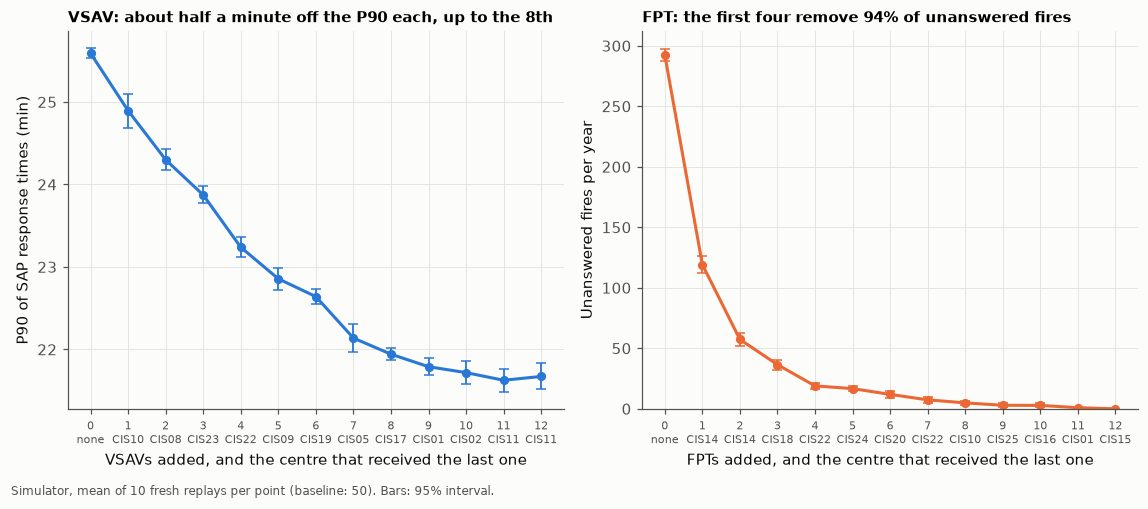

In [7]:
fg.reinforcement_curves(curve_v, curve_f)

- **The search flatters its own picks.** Fresh replays are worse than the greedy said by up to 0.4 min on the P90
  and 8 fires (5th FPT: 9 said, 17 measured). Only the confirmed values are used below.
- **Four FPTs do the work on fires**: 292 to 19 a year, minus 94%. Two at CIS14, one at CIS18, a second one at
  CIS22. Each FPT after that saves fewer than 5 fires a year, and which centre gets it is a near tie.
- **VSAVs pay steadily up to about 8**: around half a minute of P90 each, 25.6 to 21.9 min in all. After that each
  one is worth 0.15 min or less, inside the noise, and the 12th changes nothing.

## 5. The Pareto front

Since each objective depends on one vehicle type, a split of v VSAV and f FPT is scored from the two confirmed
curves: its P90 is the v-th VSAV point, its fire count the f-th FPT point. That gives 91 splits of at most 12
vehicles. Section 6 checks this on real combined runs.

90 of 91 splits are on the front


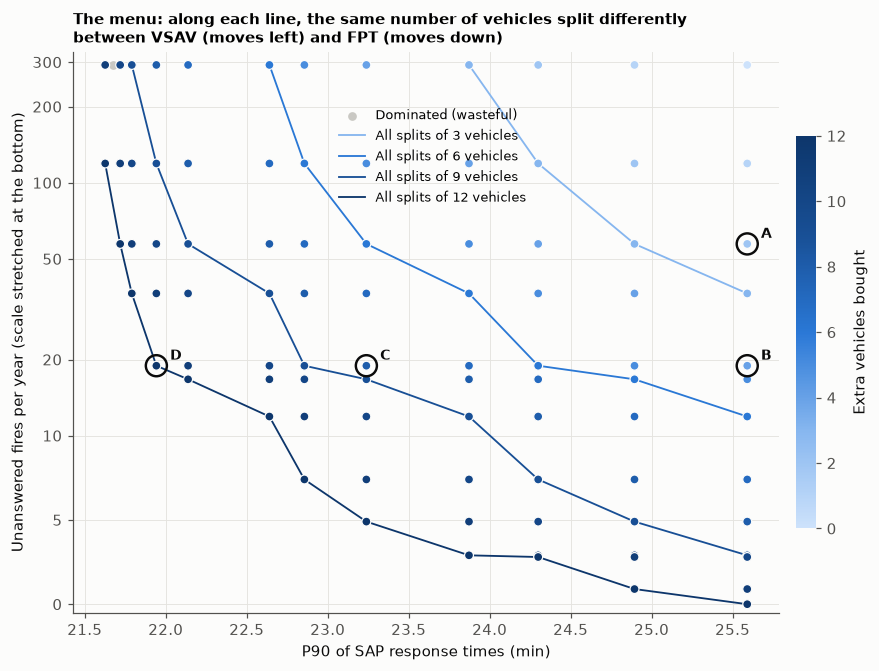

In [8]:
splits = [(v, f) for v in curve_v.index for f in curve_f.index if v + f <= sim.MAX_VEHICLES]
front = pd.DataFrame([{"VSAV": v, "FPT": f, "vehicles": v + f,
                       "p90": curve_v.loc[v, "mean"], "inc": curve_f.loc[f, "mean"]} for v, f in splits])
front["pareto"] = sim.pareto_mask(front[["p90", "inc", "vehicles"]])
front.round(2).to_csv(h.RESULTS / "pareto_front.csv", index=False)

picks = pd.DataFrame([("A", 0, 2), ("B", 0, 4), ("C", 4, 4), ("D", 8, 4)], columns=["label", "VSAV", "FPT"])
picks = picks.merge(front, on=["VSAV", "FPT"])
print(f"{front['pareto'].sum()} of {len(front)} splits are on the front")
fg.tradeoff_front(front, picks)

- **Almost every split is on the front.** With cost as an objective, a cheaper plan is never beaten by a dearer
  one, so the front is a whole surface. The only grey point is 12 VSAV and no FPT: the 12th VSAV buys nothing,
  so 11 VSAV do as well for less.
- **The front shows the menu, not the choice.** Along each line the money is the same, and choosing a point means
  deciding how many minutes of P90 one unanswered fire is worth. That judgement belongs to the service. The curves
  make it easy for the first vehicles and hard for the last.

## 6. Four recommendations

Each one contains the previous one, so the service can buy in stages without regret. All start with FPTs,
because no VSAV comes close: the first FPT saves about 170 fires a year, the first VSAV 0.7 min of P90. Each is
replayed 20 times as a whole, which also checks the split assumption on real combinations.

In [9]:
def placement(v, f):
    # VSAV part of the v-th greedy step plus FPT part of the f-th
    config = {}
    for path, k in ((vsav_path, v), (fpt_path, f)):
        for cis, per_type in (path.loc[k, "config"] if k else {}).items():
            config.setdefault(cis, {}).update(per_type)
    return config


def where(config):
    return "; ".join(
        f"{t}: " + ", ".join(c + (f" x{k[t]}" if k[t] > 1 else "") for c, k in sorted(config.items()) if t in k)
        for t in ("FPT", "VSAV") if any(t in k for k in config.values()))


picks["config"] = [placement(v, f) for v, f in zip(picks["VSAV"], picks["FPT"])]
joint = {p.label: sim.evaluate(p.config, 20, tag="E_joint", reserve=RESERVE) for p in picks.itertuples()}
table = show(joint)
table["predicted from the curves"] = [f"{p.p90:.2f} min, {p.inc:.0f} fires" for p in picks.itertuples()]
table["where"] = [where(c) for c in picks["config"]]
picks["p90"], picks["inc"] = [joint[x]["p90"] for x in picks["label"]], [joint[x]["inc"] for x in picks["label"]]
table.to_csv(h.RESULTS / "recommendations.csv")
table

,vehicles,replays,P90 SAP (min),unanswered fires,predicted from the curves,where
A,2,20,25.63 ± 0.09,59 ± 4,"25.59 min, 57 fires",FPT: CIS14 x2
B,4,20,25.61 ± 0.10,19 ± 3,"25.59 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22"
C,8,20,23.17 ± 0.07,19 ± 2,"23.24 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22; VSAV: CIS08, CIS10, CIS22, CIS23"
D,12,20,21.96 ± 0.09,19 ± 2,"21.94 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22; VSAV: CIS05, CIS08, CIS09, CIS10, CIS17, CIS19, CIS22, CIS23"


**Who benefits.** The simulator only returns department-wide figures, so this is read from the plan and from 2025:
the communes where a reinforced centre is among the first three called, and what went wrong there last year.

In [10]:
slow_sap = iv[(iv["reason"] == "SAP") & (iv["delay_min"] > 20)].groupby("insee").size()  # 20 min = SAP threshold
zones = raw["communes"].set_index("insee")["zone_sdacr"]


def reached(config, vehicle):
    near = plan[(plan["rang"] <= 3) & plan["code_cis"].isin([c for c, k in config.items() if vehicle in k])]
    return near["insee"].unique()


benefit = {}
for p in picks.itertuples():
    fire, sap_ = reached(p.config, "FPT"), reached(p.config, "VSAV")
    benefit[p.label] = {
        "fires: communes reached": len(fire),
        "their 2025 unanswered fires": int(missed_fires.reindex(fire).sum()),
        "SAP: communes reached": len(sap_),
        "their 2025 SAP calls over 20 min": int(slow_sap.reindex(sap_).sum()),
        "zones reached": ", ".join(f"{z}: {n}" for z, n in zones[np.union1d(fire, sap_)].value_counts().sort_index().items()),
    }
print(f"2025 totals: {missed_fires.sum()} unanswered fires, {slow_sap.sum()} SAP calls over 20 min")
pd.DataFrame(benefit).T

2025 totals: 290 unanswered fires, 6005 SAP calls over 20 min


,fires: communes reached,their 2025 unanswered fires,SAP: communes reached,their 2025 SAP calls over 20 min,zones reached
A,15,125,0,0,"Z3: 11, Z4: 4"
B,41,145,0,0,"Z2: 3, Z3: 32, Z4: 6"
C,41,145,40,1784,"Z1: 1, Z2: 11, Z3: 42, Z4: 13"
D,41,145,86,4158,"Z1: 3, Z2: 17, Z3: 63, Z4: 22"


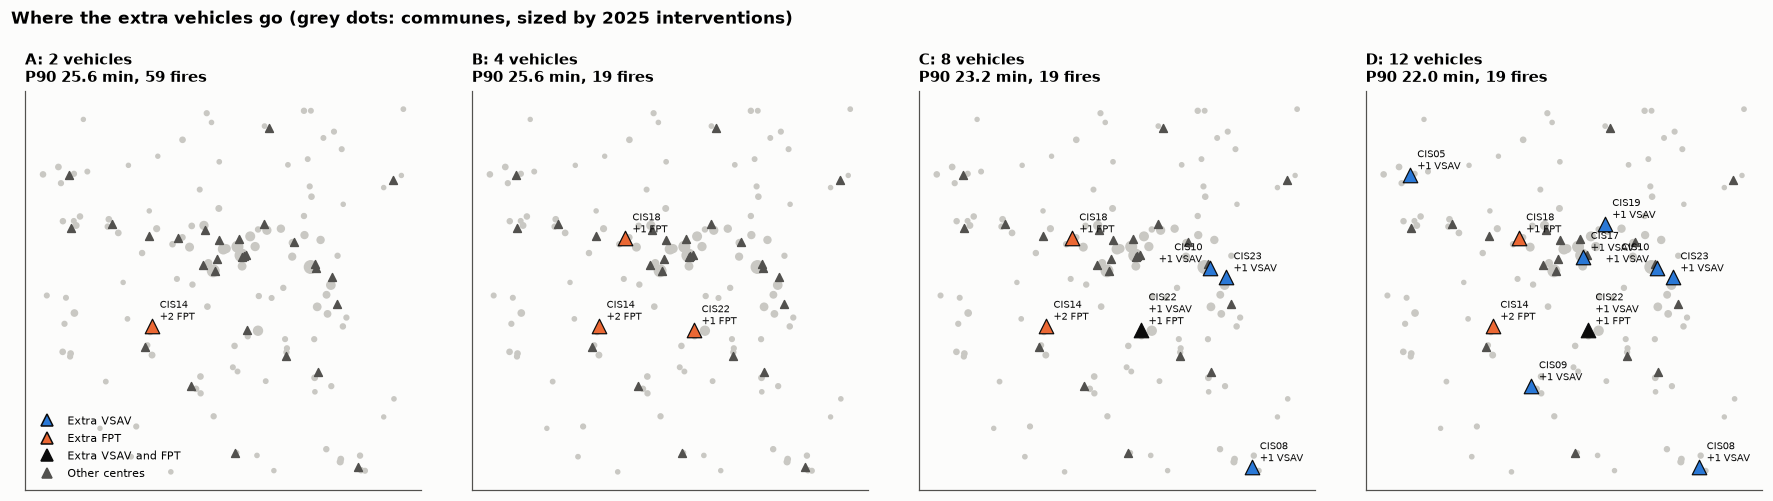

In [11]:
fg.reinforcement_map(raw, picks, iv)

- **A, 2 vehicles: two FPTs at CIS14.** Unanswered fires drop by about 80%. It serves the west and south-west, where
  CIS14, CIS24, CIS25, CIS11 and CIS09 hold no FPT today and fires wait for one from the centre.
- **B, 4 vehicles: A plus an FPT at CIS18 and a second one at CIS22.** Unanswered fires drop by about 94%, to
  roughly one every three weeks. The P90 does not move: this plan is for fires only.
- **C, 8 vehicles: B plus VSAVs at CIS10, CIS08, CIS23 and CIS22.** About 2.4 min off the P90. CIS10 and CIS23 back
  up the busy eastern town around CIS27, CIS08 is the isolated far south, CIS22 the centre-south.
- **D, 12 vehicles: C plus VSAVs at CIS09, CIS19, CIS05 and CIS17.** About 3.6 min off the P90 in all, adding the
  far west (CIS05), the south-west (CIS09) and the central towns. If the service values fires more, the other
  12-vehicle option is 6 FPT and 6 VSAV: about 7 fewer unanswered fires a year for 0.7 min more on the P90.

The beneficiaries are mostly outlying Z3 and Z4 communes, the ones Task 1 found late. Z4 has no compliance target
but its calls count in the P90. The communes reached by B's FPTs held half of 2025's unanswered fires, yet B removes
94%: the new FPTs also answer further out, and free the existing ones for everyone else.

## 7. How far to trust this

- **Noise.** Every number used for a decision is the mean of 10 to 20 fresh replays, shown with its 95% interval.
  The fire count also varies between calls more than within one (15 fires between two baseline calls), so
  differences under about 25 fires from 3-replay runs were never used to decide anything final.
- **The split VSAV for P90, FPT for fires** was tested three times: extreme configurations, the re-check, and the
  four combined plans, whose measured values match the curves within noise.
- **The search is a heuristic.** Greedy placement works well when each vehicle is worth less than the one before,
  which the curves show, but it does not prove the optimum. After 4 FPT and 8 VSAV the choice of centre is within
  noise, so other centres would do about as well there.
- **What the model leaves out.** Vehicles are counted as equal, but an FPT costs more and needs a larger crew than
  a VSAV, which matters in volunteer centres. The simulator gives no per-commune results, so who benefits is
  inferred, not measured. The year replayed is a perturbation of 2025, not a forecast.

In [12]:
steps = {"A_noise": "noise and checks", "A_recheck": "re-check after the doubt", "B_screen": "screening",
         "C_greedy": "greedy build", "D_confirm": "confirmation", "E_joint": "final check"}
used = sim.load_runs().groupby("tag")["n"].sum().reindex(list(steps)).rename(steps).rename("replays")
print(f"Task 2 used {used.sum()} replays. Left in the simulator's own counter: {sim.budget_left()} of 2000.")
used.to_frame()

Task 2 used 950 replays. Left in the simulator's own counter: 1050 of 2000.


,replays
tag,
noise and checks,50
re-check after the doubt,40
screening,180
greedy build,360
confirmation,240
final check,80
